# Detection & Analysis of Pre-SN Outburst Simulations

[View our paper here](https://iopscience.iop.org/article/10.3847/1538-4357/ad973d) for details on our cleaning and binning method, as well as our pre-SN outburst detection process!

## Settings 
### Load the config file and preset column names

In [1]:
# ==== User Settings ====

# Enter the config file name:
CONFIG_FILE = "config.ini"

# Enter the column name preset to use 
# (see config file for more; options: "atlas", "rubin", "tess"):
PRESET = "atlas"

# =======================

import sys
import numpy as np
import pandas as pd
from typing import Optional, List
import matplotlib.pyplot as plt

from download import load_config, make_dir_if_not_exists
from lightcurve import PresetColumnNames, Supernova, AveragedSupernova, LightCurve, SimDetecLightCurve, SimDetecSupernova
from plot import Plot, PlotLimits
from utils import reformat_dir, get_config_flags, get_inverse_mjd_ranges
from generate_detec_table import ContaminationTable, Model, SimDetecTable, SimDetecTables, EfficiencyTable, AtlasSimDetecLoop

# load config
config = load_config(CONFIG_FILE)

# load preset
print(f"\nLoading {PRESET} preset column names from {CONFIG_FILE}...")
colnames = PresetColumnNames(config, PRESET)
print(colnames.__str__())


Loading config file at config.ini...

Loading atlas preset column names from config.ini...
--- Required Columns ---
mjd: MJD
flux: uJy
dflux: duJy
--- Optional Columns ---
chisquare: chi/N
filt: F
mag: m
dmag: dm
ra: RA
dec: Dec
--- Extra Columns to Copy ---
x, y, maj, min, phi, apfit, mag5sig, Sky, Obs


### Load the light curves

In [2]:
# ==== User Settings ====

# Enter the target SN name:
TNSNAME = '2019vxm'

# Enter the path to the data directory that contains the ATClean-readable SN directories:
INPUT_DIR = config["dir"]["atclean_input"]

# Enter the path to the directory that contains cleaned and binned light curves, plots, and more:
OUTPUT_DIR = config["dir"]["output"]

# Automatically save the generated plots in this notebook?:
SAVE_PLOTS = False
# Enter the path to a directory to optionally save plots:
PLOTS_DIR = f'{OUTPUT_DIR}/{TNSNAME}/bump_analysis/plots'

# Enter the filter for this light curve:
FILT = 'o'

# Enter the SN's discovery date:
DISCOVERY_DATE = 58650.0

# Enter the size of the MJD bins (in days):
MJD_BIN_SIZE = 1.0

# Enter the number of control light curves to load:
NUM_CONTROLS = 7 #int(config["download"]["num_controls"])

# =======================

# make sure tnsname not attached to end of input and output dirs
INPUT_DIR = reformat_dir(INPUT_DIR, TNSNAME)
OUTPUT_DIR = reformat_dir(OUTPUT_DIR, TNSNAME)

print(f'SN {TNSNAME}, filter {FILT}', end='')
if not DISCOVERY_DATE is None:
    print(f', discovery date: {DISCOVERY_DATE}')
print(f'Output directory (load cleaned and binned light curves): {OUTPUT_DIR}/{TNSNAME}')
print(f'Plots directory (save plots): {PLOTS_DIR}')

# load cleaned light curves
sn = Supernova(colnames, tnsname=TNSNAME, mjd0=DISCOVERY_DATE, filt=FILT)
sn.load_all(OUTPUT_DIR, NUM_CONTROLS, cleaned=True)

# load binned light curves
avg_sn = SimDetecSupernova(colnames, tnsname=TNSNAME, mjdbinsize=MJD_BIN_SIZE, mjd0=DISCOVERY_DATE, filt=FILT)
avg_sn.load_all(OUTPUT_DIR, NUM_CONTROLS)

p = Plot(PLOTS_DIR)

config_flags = get_config_flags(config)

SN 2019vxm, filter o, discovery date: 58650.0
Output directory (load cleaned and binned light curves): /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2019vxm
Plots directory (save plots): /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2019vxm/bump_analysis/plots

Loading SN light curve and 7 control light curves...
could not read /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2019vxm/controls/2019vxm_i001.o.clean.lc.txt!
Could not load control light curve 1; skipping...
Successfully loaded SN light curve and 7 control light curves (control indices: [2, 3, 4, 5, 6, 7, 8])
Updating column names for all light curves in this Supernova object (key: dflux_new, name: duJy_new)...

Loading averaged SN light curve and 7 averaged control light curves...
could not read /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2019vxm/controls/2019vxm_i001.o.1.00days.lc.txt!
Could not load averaged control light curve 1; skipping...
Successfully loa

## Plot cleaned original and binned pre-SN light curves

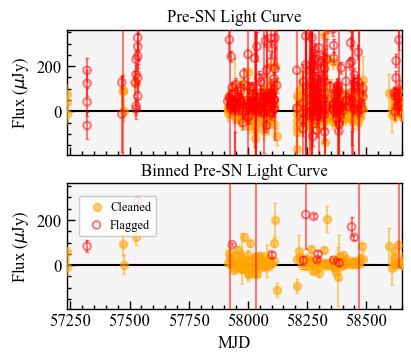

In [3]:
# ==== User Settings ====

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = None
YLIM_UPPER = None

# =======================

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

fig = p.plot_preSN(
    sn, 
    avg_sn, 
    config_flags,
    custom_lims=custom_lims,
    save=SAVE_PLOTS
)

## Plot all control light curves

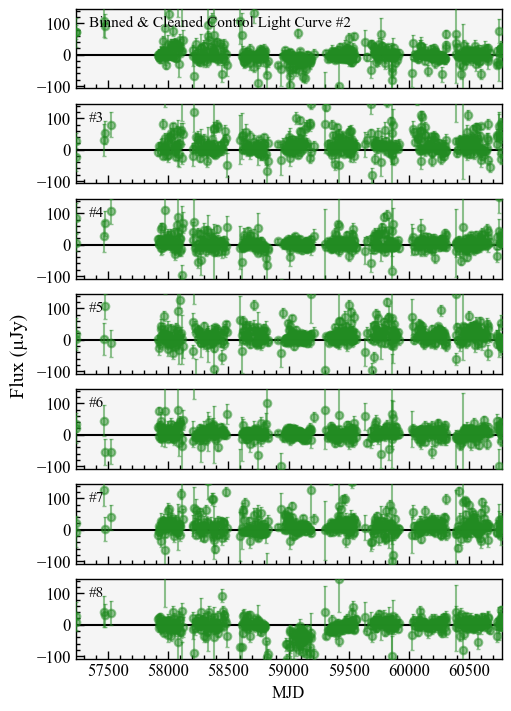

In [4]:
# ==== User Settings ====

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = None
YLIM_UPPER = None

# =======================

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

fig = p.plot_all_controls(
    avg_sn, 
    config_flags,
    custom_lims=custom_lims,
    two_columns=False,
    save=SAVE_PLOTS
)

## Plot binned pre-SN and control light curve

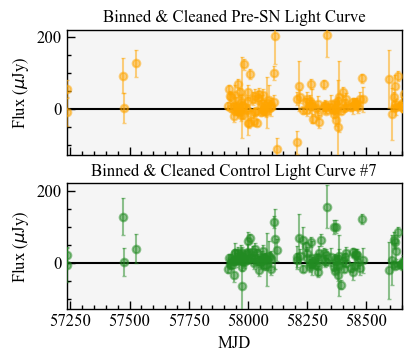

In [5]:
# ==== User Settings ====

# Enter the index of the control light curve to plot:
SELECT_CONTROL_INDEX = 7

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = None
YLIM_UPPER = None

# =======================

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

fig = p.plot_binned_examples(
    avg_sn, 
    SELECT_CONTROL_INDEX, 
    config_flags,
    custom_lims=custom_lims, 
    save=SAVE_PLOTS
)

## Get detection limits w.r.t. contamination

We use the bisection method to calculate the best detection limits $\Sigma_{\text{FOM, limit}}$ for each $\sigma_{\text{kernel}}$ with respect to a target contamination value.

We measure contamination for a given $\sigma_{\text{kernel}}$ and its corresponding $\Sigma_{\text{FOM, limit}}$ by counting the number of false positives in the control light curves (where a single false positive is defined by a continuous sequence of $\Sigma_{\text{FOM}}$ above $\Sigma_{\text{FOM, limit}}$). We record two alternative measures of contamination for evaluating a certain $\Sigma_{\text{FOM, limit}}$:

1. the number of positive control light curves (default option)
2. the total number of false positives throughout all control light curve

#### Plot observation seasons

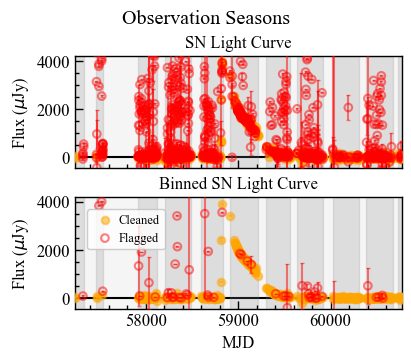

In [6]:
# ==== User Settings ====

# List the observation seasons
MJD_RANGES: List[List[int]] = [
    [57233, 57329], 
    [57466, 57536], 
    [57914, 58123],
    [58206, 58487],
    [58594, 58837],
    [58910, 59213],
    [59304, 59565],
    [59637, 59916],
    [60023, 60310],
    [60387, 60672],
    [60727, 60771]
]

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = None
YLIM_UPPER = None

# =======================

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

fig = p.plot_mjd_ranges(
    sn, 
    avg_sn, 
    config_flags,
    MJD_RANGES,
    suptitle="Observation Seasons",
    custom_lims=custom_lims,
    filename="observation_seasons",
    save=SAVE_PLOTS
)

### Exclude bad MJD ranges and determine valid observation seasons

Min MJD: 57233.0, max MJD: 60770.0
Observation season ranges: [[57233, 57329], [57466, 57536], [57914, 58123], [58206, 58487], [58594, 58837], [58910, 59213], [59304, 59565], [59637, 59916], [60023, 60310], [60387, 60672], [60727, 60771]]
Excluding additional MJD ranges [[57233.0, 57329], [57466, 57536]]...
Expanding range edges by 20...
Excluded MJD ranges (observation season gaps plus expanded edges and additional excluded ranges): 
	[[57233.0, 57933], [58104, 58225], [58468, 58613], [58818, 58929], [59194, 59323], [59546, 59656], [59897, 60042], [60291, 60406], [60653, 60746]]
Included ranges: 
	[[57934, 58103], [58226, 58467], [58614, 58817], [58930, 59193], [59324, 59545], [59657, 59896], [60043, 60290], [60407, 60652], [60747, 60770.0]]


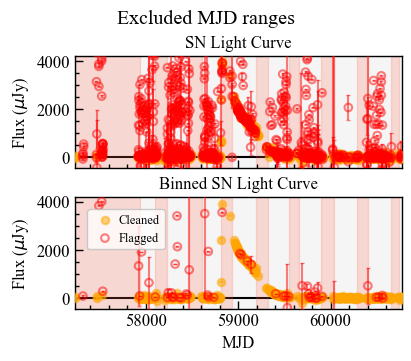

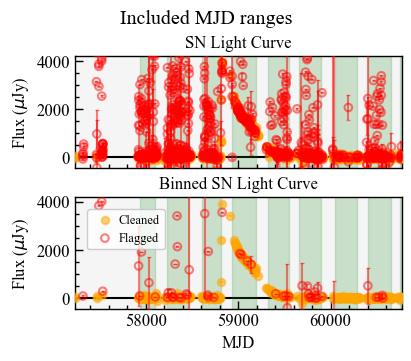

In [7]:
# ==== User Settings ====

# Optionally expand observation gap MJD ranges by +-exclude_obs_edges days on either side 
# (set to None or 0 to skip):
EXPAND_EDGES = 20

# Optionally exclude additional bad observation seasons or arbitrary ranges 
# (set to None or empty list [] to skip):
EXCLUDE_MJD_RANGES: List[List[int]] = [
    MJD_RANGES[0],
    MJD_RANGES[1]
]

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = None
YLIM_UPPER = None

# =======================

min_mjd, max_mjd = avg_sn.lcs[0].get_min_and_max_mjd()
print(f'Min MJD: {min_mjd}, max MJD: {max_mjd}')

print(f'Observation season ranges: {MJD_RANGES}')

excluded_mjd_ranges = get_inverse_mjd_ranges(
    MJD_RANGES, 
    min_mjd, 
    max_mjd, 
    expand_edges=EXPAND_EDGES,
    exclude_mjd_ranges=EXCLUDE_MJD_RANGES
)
print(f'Excluded MJD ranges (observation season gaps plus expanded edges and additional excluded ranges): \n\t{excluded_mjd_ranges}')

included_mjd_ranges = get_inverse_mjd_ranges(excluded_mjd_ranges, min_mjd, max_mjd)
print(f"Included ranges: \n\t{included_mjd_ranges}")

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

fig = p.plot_mjd_ranges(
    sn, 
    avg_sn, 
    config_flags,
    excluded_mjd_ranges,
    suptitle="Excluded MJD ranges",
    range_color="tomato",
    custom_lims=custom_lims,
    filename="excluded_mjd_ranges",
    save=SAVE_PLOTS
)

fig = p.plot_mjd_ranges(
    sn, 
    avg_sn, 
    config_flags,
    included_mjd_ranges,
    suptitle="Included MJD ranges",
    range_color="forestgreen",
    custom_lims=custom_lims,
    filename="included_mjd_ranges",
    save=SAVE_PLOTS
)

### Calculate the preliminary range of valid detection limits $\Sigma_{\text{FOM, limit}}$

As our starting range of valid detection limits $\Sigma_{\text{FOM, limit}}$ for each $\sigma_{\text{kernel}}$, we set our lower limit to 0 and our upper limit to the maximum $\Sigma_{\text{FOM}}$ value across all control light curves.

In [8]:
# ==== User Settings ====

# Enter possible sigma kernels of the weighted gaussian rolling sum:
SIGMA_KERNS = [5, 15, 25, 40, 80, 130, 200, 300]

# Exclude certain control lcs from the analysis 
# (set to None or empty list [] for no exclusions):
SKIP_CONTROL_INDICES = [2, 3]

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = None
YLIM_UPPER = None

# =======================

print(f"Skipping control light curves: {SKIP_CONTROL_INDICES}")
avg_sn.remove_lc_indices(SKIP_CONTROL_INDICES)

prelim_fom_limit_ranges = avg_sn.get_prelim_fom_limit_ranges(
    SIGMA_KERNS,
    included_mjd_ranges,
)

Skipping control light curves: [2, 3]
Getting preliminary valid FOM limit range...
Getting all control FOM for MJD ranges [[57934, 58103], [58226, 58467], [58614, 58817], [58930, 59193], [59324, 59545], [59657, 59896], [60043, 60290], [60407, 60652], [60747, 60770.0]]...
Valid FOM limit ranges: {5: [0.0, 16.31], 15: [0.0, 36.65], 25: [0.0, 56.77], 40: [0.0, 79.0], 80: [0.0, 108.6], 130: [0.0, 128.13], 200: [0.0, 160.36], 300: [0.0, 213.62]}


### Calculate contamination for preliminary detection limits $\Sigma_{\text{FOM, limit}}$

In [9]:
contam = ContaminationTable()
contam.construct_prelim_t(
    avg_sn, 
    included_mjd_ranges, 
    SIGMA_KERNS, 
    prelim_fom_limit_ranges
)

print(contam)

    sigma_kern  fom_limit  n_falsepos  n_pos_controls  pct_pos_controls  n_falsepos_00  n_falsepos_04  n_falsepos_05  n_falsepos_06  n_falsepos_07  n_falsepos_08
0            5       0.00         136               5             71.43              1             30             19             33             22             32
1            5      16.31           0               0              0.00              1              0              0              0              0              0
2           15       0.00          41               5             71.43              1              9              4              9              7             12
3           15      36.65           0               0              0.00              1              0              0              0              0              0
4           25       0.00          24               5             71.43              1              6              2              5              4              7
5           25      56.77   